C:\Users\maria\AppData\Local\Temp\ipykernel_15680\1309212259.py:69: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


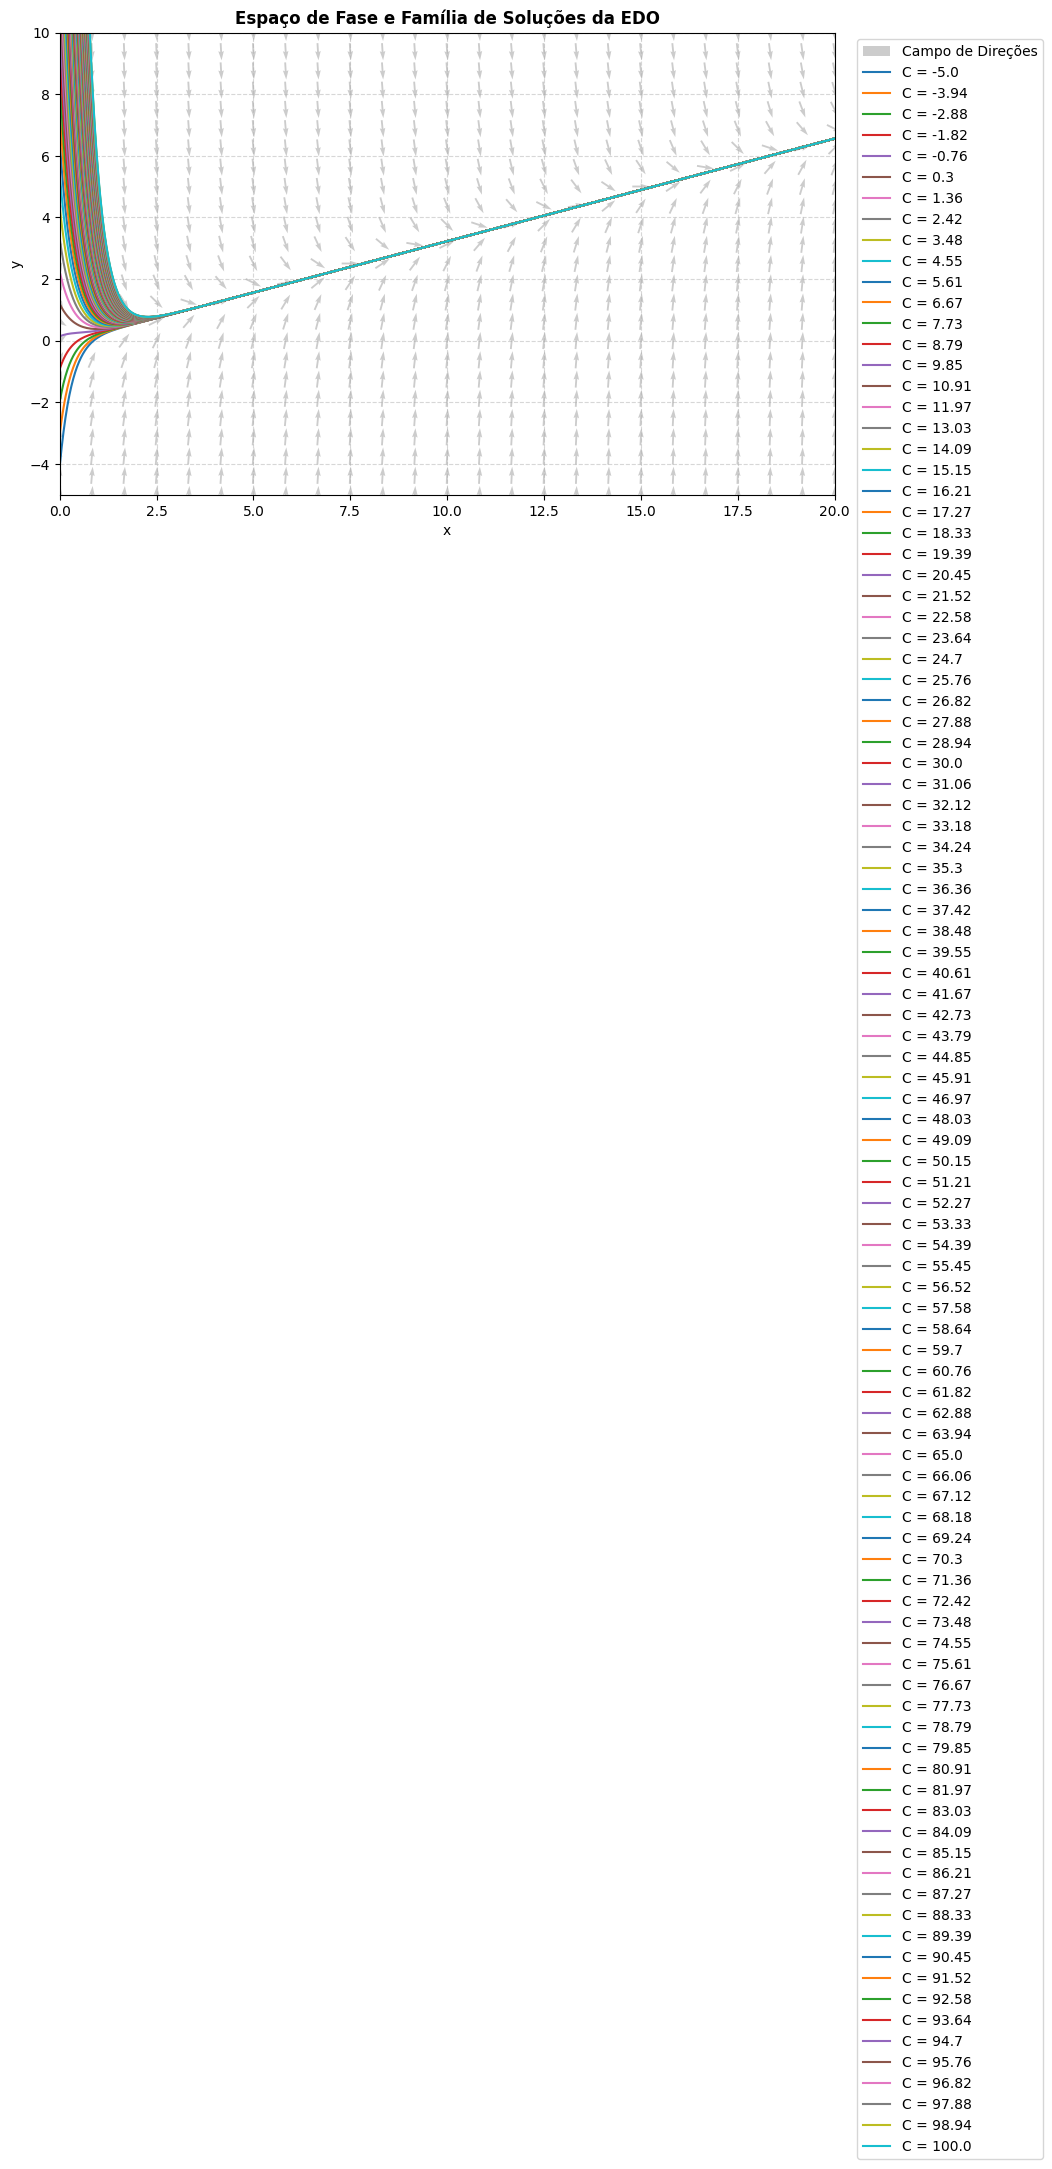

In [ ]:
import sympy as sp
import numpy as np
from scipy import special
import matplotlib.pyplot as plt

def solve_linear_ode(p_expr, q_expr, x_var):
    """
    Resolve simbolicamente uma EDO linear de 1ª ordem: y' + p(x)y = q(x)
    Retorna a expressão simbólica geral em função de x_var e de uma constante C.
    """
    C = sp.symbols('C')
    mu = sp.exp(sp.integrate(p_expr, x_var))
    integral_part = sp.integrate(mu * q_expr, x_var)
    y_expr = (integral_part + C) / mu
    
    return y_expr, C

def plot_ode_family(y_func, dydx_func=None, x_range=(0, 15), y_range=(-5, 5), C_values=None):
    """
    Renderiza a família de soluções e, opcionalmente, o campo de direções.
    """
    x_vals = np.linspace(x_range[0], x_range[1], 400)
    C_values = C_values if C_values is not None else np.linspace(-5, 15, 15)

    plt.figure(figsize=(10, 6))

    # --- INJEÇÃO DO CAMPO DE DIREÇÕES ---
    if dydx_func is not None:
        # Criamos um grid 2D menos denso para não poluir visualmente o quiver
        x_mesh = np.linspace(x_range[0], x_range[1], 25)
        y_mesh = np.linspace(y_range[0], y_range[1], 25)
        X, Y = np.meshgrid(x_mesh, y_mesh)
        
        # Avaliamos dy/dx na malha. O deslocamento em x (dx) é sempre 1.
        dY = dydx_func(X, Y)
        dX = np.ones_like(dY)
        
        # Normalização dos vetores para criar um 'slope field' puro (setas de tamanho igual)
        norm = np.sqrt(dX**2 + dY**2)
        # Evita divisão por zero em casos de singularidade ou derivadas extremas
        norm = np.where(norm == 0, 1, norm) 
        dX, dY = dX / norm, dY / norm
        
        plt.quiver(X, Y, dX, dY, color='gray', alpha=0.4, angles='xy', pivot='mid', label='Campo de Direções')
    # ------------------------------------

    # Plotagem da família de soluções (Atratores)
    for c_val in C_values:
        y_vals = np.real(y_func(x_vals, c_val))
        
        # Opcional: mascarar valores muito fora do limite do eixo Y para otimizar o Matplotlib
        y_vals = np.ma.masked_outside(y_vals, y_range[0]*2, y_range[1]*2)
        
        plt.plot(x_vals, y_vals, linewidth=1.5, label=f'C = {round(c_val, 2)}')

    plt.title("Espaço de Fase e Família de Soluções da EDO", fontsize=12, fontweight='bold')
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim(x_range)
    plt.ylim(y_range)
    
    # Gerenciamento de legenda para não poluir o gráfico
    handles, labels = plt.gca().get_legend_handles_labels()
    # Remove duplicatas da legenda do Quiver caso esteja em um loop (não é, mas é boa prática)
    by_label = dict(zip(labels, handles))
    #plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.02, 1), loc='upper left')
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    x = sp.symbols('x')
    y_sym = sp.symbols('y') # Símbolo necessário para a derivada
    
    p = 3
    q = x + sp.exp(-2*x)

    # 1. Pipeline Analítico
    y_expr, C = solve_linear_ode(p, q, x)
    
    # 2. Pipeline Numérico - Solução
    y_func_raw = sp.lambdify((x, C), y_expr, modules=['numpy', 'scipy'])
    
    # 3. Pipeline Numérico - Derivada para o Slope Field
    # y' + py = q  =>  y' = q - py
    dydx_expr = q - p * y_sym
    
    # Para expressões que possam resultar em uma constante (ex: se p=0 e q=1), 
    # np.vectorize assegura que um array seja retornado quando X, Y (matrizes) forem passados.
    dydx_func_raw = np.vectorize(sp.lambdify((x, y_sym), dydx_expr, modules=['numpy']))
    
    # 4. Renderização
    plot_ode_family(
        y_func=y_func_raw, 
        dydx_func=dydx_func_raw, 
        C_values=np.linspace(-5, 100, 100), 
        y_range=(-5, 10), 
        x_range=(0, 20)
    )